# Supply Chain Delivery and Inventory Risk

**Author: Tajamul Khan**

Which suppliers miss delivery commitments?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A distributor needs to prioritize supplier discussions using comparable delivery measures.

Measure on-time-in-full delivery and identify low inventory coverage.

## Data contract and KPI definitions

One row per purchase order with a separate illustrative inventory snapshot for that order. OTIF requires both actual_days ≤ promised_days and full units delivered; fill rate is total delivered / total ordered. Coverage = stock / daily demand. Snapshot counts are not unique SKU counts.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (2600, 9)


,po_id,date,supplier,ordered_units,delivered_units,promised_days,actual_days,stock_units,daily_demand
0,1,2025-09-29,Beacon,50,50,4,5,692,26
1,2,2025-10-09,Aster,94,94,14,13,258,50
2,3,2025-12-13,Beacon,168,168,3,3,78,36
3,4,2025-03-13,Delta,94,94,12,12,208,32
4,5,2025-10-24,Beacon,187,187,15,17,375,56


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
po_id,int64,0,2600
date,datetime64[ns],0,365
supplier,object,0,4
ordered_units,int64,0,230
delivered_units,int64,0,245
promised_days,int64,0,14
actual_days,int64,0,19
stock_units,int64,0,759
daily_demand,int64,0,60


## Action: analysis

Validate ordered versus delivered units, combine timeliness and completeness at purchase-order grain and inspect supplier coverage.

In [3]:
assert df.po_id.is_unique and (df.delivered_units<=df.ordered_units).all()
df['otif']=((df.actual_days<=df.promised_days)&(df.delivered_units==df.ordered_units)).astype(int)
df['coverage_days']=df.stock_units/df.daily_demand
summary=df.groupby('supplier').agg(orders=('po_id','size'),otif_rate=('otif','mean'),ordered=('ordered_units','sum'),delivered=('delivered_units','sum'))
summary['fill_rate_pct']=100*summary.delivered/summary.ordered
metrics={'OTIF (%)':100*df.otif.mean(),'Unit fill rate (%)':100*df.delivered_units.sum()/df.ordered_units.sum(),'Snapshots below 7 days coverage':int((df.coverage_days<7).sum())}
chart=summary.otif_rate*100; ylabel='On-time-in-full orders (%)'

## Deep dive: Supplier delay severity

A binary on-time flag treats one day and several days late equally. Add the mean positive delay and compare fill rate.

Beacon has the lowest OTIF rate (21.90%). Review lane mix, order size and delay causes before changing suppliers.
Out[4]: 114


,mean_late_days,p90_late_days,median_coverage_days
supplier,,,
Aster,1.382,4.0,11.669
Beacon,1.516,4.0,11.598
Cedar,1.538,4.0,11.857
Delta,1.368,4.0,12.070


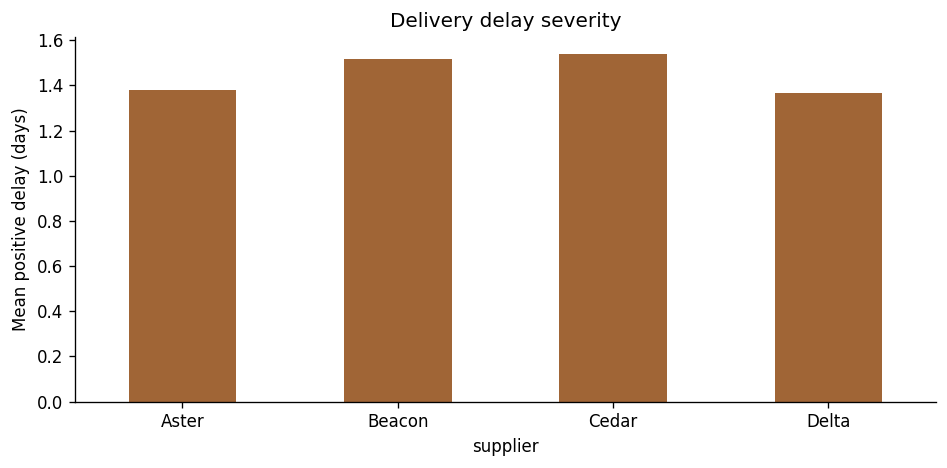

In [4]:

df['late_days']=(df.actual_days-df.promised_days).clip(lower=0)
detail=df.groupby('supplier').agg(mean_late_days=('late_days','mean'),p90_late_days=('late_days',lambda x:x.quantile(.9)),median_coverage_days=('coverage_days','median'))
display(detail.round(3))
fig,ax=plt.subplots(figsize=(8,4));detail.mean_late_days.plot.bar(ax=ax,color='#a06536',rot=0);ax.set_ylabel('Mean positive delay (days)');ax.set_title('Delivery delay severity');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
worst=summary.otif_rate.idxmin()
recommendation=f'{worst} has the lowest OTIF rate ({summary.loc[worst,"otif_rate"]:.2%}). Review lane mix, order size and delay causes before changing suppliers.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,orders,otif_rate,ordered,delivered,fill_rate_pct
supplier,,,,,
Aster,670,0.2433,90735,87920,96.8976
Beacon,630,0.2190,82769,80084,96.7560
Cedar,677,0.2334,91395,88620,96.9637
Delta,623,0.2873,84436,82001,97.1162


,value
OTIF (%),24.538462
Unit fill rate (%),96.934175
Snapshots below 7 days coverage,777.000000


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['orders']


,supplier,orders,otif_pct
0,Aster,670,24.328358
1,Beacon,630,21.904762
2,Cedar,677,23.338257
3,Delta,623,28.731942


## Visual interpretation

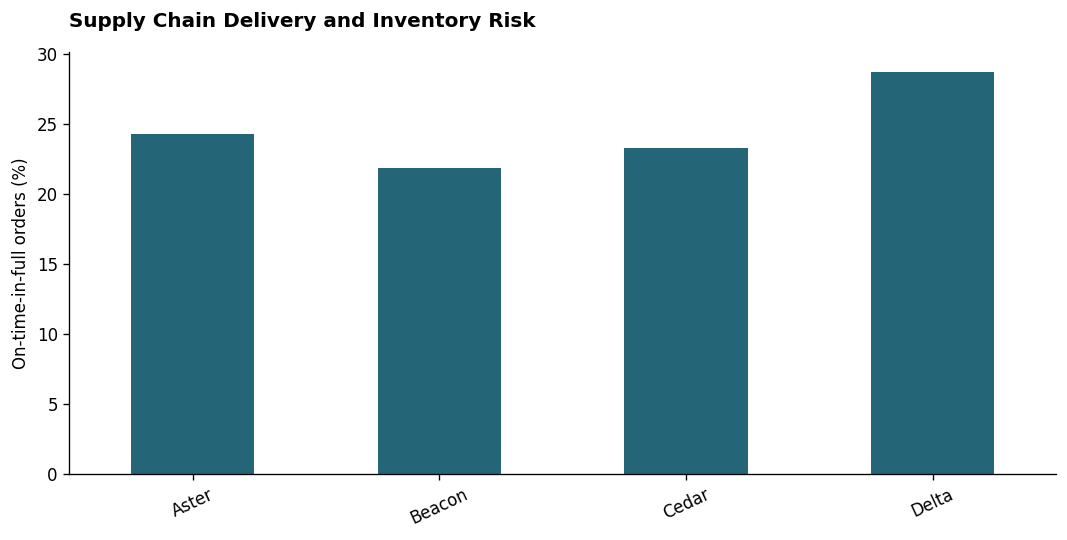

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Supply Chain Delivery and Inventory Risk',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Supply Chain Delivery and Inventory Risk</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Supply Chain Delivery and Inventory Risk</h1><p>Which suppliers miss delivery commitments?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>Coverage is a snapshot heuristic using average daily demand. It omits variability, replenishment timing and service-level safety stock.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

Coverage is a snapshot heuristic using average daily demand. It omits variability, replenishment timing and service-level safety stock.

**Next step:** Introduce SKU-level demand distributions and validate an inventory policy over time.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.